<a href="https://colab.research.google.com/github/JavierJCP/30-Days-Of-Python/blob/master/chapters/chap02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Puedes pedir las versiones impresa y ebook de *Think Python 3e* en
[Bookshop.org](https://bookshop.org/a/98697/9781098155438) y
[Amazon](https://www.amazon.com/_/dp/1098155432?smid=ATVPDKIKX0DER&_encoding=UTF8&tag=oreilly20-20&_encoding=UTF8&tag=greenteapre01-20&linkCode=ur2&linkId=e2a529f94920295d27ec8a06e757dc7c&camp=1789&creative=9325).

In [1]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + str(local))
    return filename

download('https://github.com/AllenDowney/ThinkPython/raw/v3/thinkpython.py');
download('https://github.com/AllenDowney/ThinkPython/raw/v3/diagram.py');

import thinkpython

Downloaded thinkpython.py
Downloaded diagram.py


# Variables y sentencias

En el capítulo anterior usamos operadores para escribir expresiones que realizan cálculos aritméticos.

En este capítulo aprenderás sobre variables y sentencias, la sentencia `import` y la función `print`.
Y presentaré más vocabulario que usamos para hablar de programas, incluyendo "argumento" y "módulo".


## Variables

Una **variable** es un nombre que se refiere a un valor.
Para crear una variable, podemos escribir una **sentencia de asignación** como esta.

In [8]:
n = 17

Una sentencia de asignación tiene tres partes: el nombre de la variable a la izquierda, el operador igual, `=`, y una expresión a la derecha.
En este ejemplo, la expresión es un entero.
En el siguiente ejemplo, la expresión es un número de punto flotante.

In [3]:
pi = 3.141592653589793

Y en el siguiente ejemplo, la expresión es un string.

In [6]:
message = 'And now for something completely different'

Cuando ejecutas una sentencia de asignación, no hay salida.
Python crea la variable y le da un valor, pero la sentencia de asignación no tiene ningún efecto visible.
Sin embargo, después de crear una variable, puedes usarla como una expresión.
Así que podemos mostrar el valor de `message` así:

In [7]:
message

'And now for something completely different'

También puedes usar una variable como parte de una expresión con operadores aritméticos.

In [9]:
n + 25

42

In [10]:
2 * pi

6.283185307179586

Y puedes usar una variable cuando llamas a una función.

In [11]:
round(pi)

3

In [12]:
len(message)

42

## Diagramas de estado

Una forma común de representar variables en papel es escribir el nombre con una flecha apuntando a su valor.

In [13]:
import math

from diagram import make_binding, Frame

binding = make_binding("message", 'And now for something completely different')
binding2 = make_binding("n", 17)
binding3 = make_binding("pi", 3.141592653589793)

frame = Frame([binding2, binding3, binding])

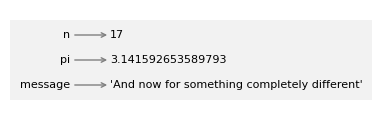

In [14]:
from diagram import diagram, adjust


width, height, x, y = [3.62, 1.01, 0.6, 0.76]
ax = diagram(width, height)
bbox = frame.draw(ax, x, y, dy=-0.25)
# adjust(x, y, bbox)

Este tipo de figura se llama **diagrama de estado** porque muestra en qué estado está cada una de las variables (piensa en ello como el estado mental de la variable).
Usaremos diagramas de estado a lo largo del libro para representar un modelo de cómo Python almacena variables y sus valores.

## Nombres de variables

Los nombres de variables pueden ser tan largos como quieras. Pueden contener letras y números, pero no pueden comenzar con un número.
Es válido usar letras mayúsculas, pero lo convencional es usar solo minúsculas para los nombres de variables.

El único signo de puntuación que puede aparecer en un nombre de variable es el carácter de guion bajo, `_`. Se usa a menudo en nombres con varias palabras, como `your_name` o  `airspeed_of_unladen_swallow`.

Si le das a una variable un nombre no válido, obtienes un error de sintaxis.
El nombre `million!` no es válido porque contiene puntuación.

In [15]:
%%expect SyntaxError

million! = 1000000

SyntaxError: invalid syntax (4061783710.py, line 1)

`76trombones` no es válido porque empieza con un número.

In [16]:
%%expect SyntaxError

76trombones = 'big parade'

SyntaxError: invalid decimal literal (3636686625.py, line 1)

`class` tampoco es válido, pero puede que no sea obvio por qué.

In [17]:
%%expect SyntaxError

class = 'Self-Defence Against Fresh Fruit'

SyntaxError: invalid syntax (3285659805.py, line 1)

Resulta que `class` es una **palabra clave**, que es una palabra especial usada para especificar la estructura de un programa.
Las palabras clave no se pueden usar como nombres de variables.

Aquí tienes una lista completa de las palabras clave de Python:

```
False      await      else       import     pass
None       break      except     in         raise
True       class      finally    is         return
and        continue   for        lambda     try
as         def        from       nonlocal   while
assert     del        global     not        with
async      elif       if         or         yield
```

In [18]:
from keyword import kwlist

len(kwlist)

35

No tienes que memorizar esta lista. En la mayoría de los entornos de desarrollo, las palabras clave se muestran en un color diferente; si intentas usar una como nombre de variable, lo sabrás.

## La sentencia import

Para usar algunas características de Python, tienes que **importarlas**.
Por ejemplo, la siguiente sentencia importa el módulo `math`.

In [19]:
import math

Un **módulo** es una colección de variables y funciones.
El módulo math proporciona una variable llamada `pi` que contiene el valor de la constante matemática denotada $\pi$.
Podemos mostrar su valor así.

In [20]:
math.pi

3.141592653589793

Para usar una variable de un módulo, tienes que usar el **operador punto** (`.`) entre el nombre del módulo y el nombre de la variable.

El módulo math también contiene funciones.
Por ejemplo, `sqrt` calcula raíces cuadradas.

In [21]:
math.sqrt(25)

5.0

Y `pow` eleva un número a la potencia de un segundo número.

In [22]:
math.pow(5, 2)

25.0

En este punto hemos visto dos formas de elevar un número a una potencia: podemos usar la función `math.pow` o el operador de exponenciación, `**`.
Cualquiera de las dos está bien, pero el operador se usa más a menudo que la función.

## Expresiones y sentencias

Hasta ahora hemos visto algunos tipos de expresiones.
Una expresión puede ser un solo valor, como un entero, un número de punto flotante o un string.
También puede ser una colección de valores y operadores.
Y puede incluir nombres de variables y llamadas a funciones.
Aquí hay una expresión que incluye varios de estos elementos.

In [23]:
19 + n + round(math.pi) * 2

42

También hemos visto algunos tipos de sentencias.
Una **sentencia** es una unidad de código que tiene un efecto, pero no un valor.
Por ejemplo, una sentencia de asignación crea una variable y le da un valor, pero la sentencia en sí no tiene valor.

In [24]:
n = 17

De forma similar, una sentencia import tiene un efecto -- importa un módulo para que podamos usar las variables y funciones que contiene -- pero no tiene efecto visible.

In [25]:
import math

Calcular el valor de una expresión se llama **evaluación**.
Ejecutar una sentencia se llama **ejecución**.

## La función print

Cuando evalúas una expresión, se muestra el resultado.

In [26]:
n + 1

18

Pero si evalúas más de una expresión, solo se muestra el valor de la última.

In [27]:
n + 2
n + 3

20

Para mostrar más de un valor, puedes usar la función `print`.

In [28]:
print(n+2)
print(n+3)

19
20


También funciona con números de punto flotante y strings.

In [29]:
print('The value of pi is approximately')
print(math.pi)

The value of pi is approximately
3.141592653589793


También puedes usar una secuencia de expresiones separadas por comas.

In [30]:
print('The value of pi is approximately', math.pi)

The value of pi is approximately 3.141592653589793


Observa que la función `print` coloca un espacio entre los valores.

## Argumentos

Cuando llamas a una función, la expresión entre paréntesis se llama un **argumento**.
Normalmente explicaría por qué, pero en este caso el significado técnico de un término no tiene casi nada que ver con el significado común de la palabra, así que ni siquiera lo intentaré.

Algunas de las funciones que hemos visto hasta ahora toman solo un argumento, como `int`.

In [31]:
int('101')

101

Algunas toman dos, como `math.pow`.

In [32]:
math.pow(5, 2)

25.0

Algunas pueden tomar argumentos adicionales que son opcionales.
Por ejemplo, `int` puede tomar un segundo argumento que especifica la base del número.

In [33]:
int('101', 2)

5

La secuencia de dígitos `101` en base 2 representa el número 5 en base 10.

`round` también toma un segundo argumento opcional, que es el número de posiciones decimales al que redondear.

In [34]:
round(math.pi, 3)

3.142

Algunas funciones pueden tomar cualquier número de argumentos, como `print`.

In [35]:
print('Any', 'number', 'of', 'arguments')

Any number of arguments


Si llamas a una función y proporcionas demasiados argumentos, eso es un `TypeError`.

In [36]:
%%expect TypeError

float('123.0', 2)

TypeError: float expected at most 1 argument, got 2

Si proporcionas muy pocos argumentos, eso también es un `TypeError`.

In [37]:
%%expect TypeError

math.pow(2)

TypeError: pow expected 2 arguments, got 1

Y si proporcionas un argumento con un tipo que la función no puede manejar, eso también es un `TypeError`.

In [38]:
%%expect TypeError

math.sqrt('123')

TypeError: must be real number, not str

Este tipo de comprobación puede ser molesto cuando estás empezando, pero te ayuda a detectar y corregir errores.

## Comentarios

A medida que los programas se hacen más grandes y complicados, se vuelven más difíciles de leer.
Los lenguajes formales son densos, y a menudo es difícil mirar un fragmento de código y averiguar qué hace y por qué.

Por esta razón, es buena idea añadir notas a tus programas para explicar en lenguaje natural qué está haciendo el programa.
Estas notas se llaman **comentarios**, y empiezan con el símbolo `#`.

In [39]:
# number of seconds in 42:42
seconds = 42 * 60 + 42

En este caso, el comentario aparece en una línea por sí solo. También puedes poner comentarios al final de una línea:

In [40]:
miles = 10 / 1.61     # 10 kilometers in miles

Todo desde el `#` hasta el final de la línea se ignora---no tiene efecto en la ejecución del programa.

Los comentarios son más útiles cuando documentan características no obvias del código.
Es razonable suponer que el lector puede averiguar *qué* hace el código; es más útil explicar *por qué*.

Este comentario es redundante con el código y no sirve:

In [41]:
v = 8     # assign 8 to v

Este comentario contiene información útil que no está en el código:

In [42]:
v = 8     # velocity in miles per hour

Los buenos nombres de variables pueden reducir la necesidad de comentarios, pero los nombres largos pueden hacer que las expresiones complejas sean difíciles de leer, así que hay una compensación.

## Debugging

En un programa pueden ocurrir tres tipos de errores: errores de sintaxis, errores en tiempo de ejecución y errores semánticos.
Es útil distinguirlos para localizarlos más rápidamente.

* **Error de sintaxis**: "Sintaxis" se refiere a la estructura de un programa y a las reglas sobre esa estructura. Si hay un error de sintaxis en cualquier parte de tu programa, Python no ejecuta el programa. Muestra un mensaje de error inmediatamente.

* **Error en tiempo de ejecución**: Si no hay errores de sintaxis en tu programa, puede empezar a ejecutarse. Pero si algo sale mal, Python muestra un mensaje de error y se detiene. Este tipo de error se llama error en tiempo de ejecución. También se llama una **excepción** porque indica que ha ocurrido algo excepcional.

* **Error semántico**: El tercer tipo de error es "semántico", lo que significa relacionado con el significado. Si hay un error semántico en tu programa, se ejecuta sin generar mensajes de error, pero no hace lo que pretendías. Identificar errores semánticos puede ser complicado porque requiere que trabajes hacia atrás mirando la salida del programa e intentando averiguar qué está haciendo.

Como hemos visto, un nombre de variable no válido es un error de sintaxis.

In [43]:
%%expect SyntaxError

million! = 1000000

SyntaxError: invalid syntax (4061783710.py, line 1)

Si usas un operador con un tipo que no admite, eso es un error en tiempo de ejecución.

In [44]:
%%expect TypeError

'126' / 3

TypeError: unsupported operand type(s) for /: 'str' and 'int'

Por último, aquí tienes un ejemplo de error semántico.
Supongamos que queremos calcular la media de `1` y `3`, pero olvidamos el orden de operaciones y escribimos esto:

In [45]:
1 + 3 / 2

2.5

Cuando se evalúa esta expresión, no produce un mensaje de error, así que no hay error de sintaxis ni error en tiempo de ejecución.
Pero el resultado no es la media de `1` y `3`, así que el programa no es correcto.
Este es un error semántico porque el programa se ejecuta pero no hace lo que se pretendía.

## Glosario

**variable:**
Un nombre que se refiere a un valor.

**sentencia de asignación:**
Una sentencia que asigna un valor a una variable.

**diagrama de estado:**
Una representación gráfica de un conjunto de variables y los valores a los que se refieren.

**palabra clave:**
Una palabra especial usada para especificar la estructura de un programa.

**sentencia de importación:**
Una sentencia que lee un archivo de módulo para que podamos usar las variables y funciones que contiene.

**módulo:**
Un archivo que contiene código Python, incluyendo definiciones de funciones y a veces otras sentencias.

**operador punto:**
El operador, `.`, usado para acceder a una función en otro módulo especificando el nombre del módulo seguido de un punto y el nombre de la función.

**evaluar:**
Realizar las operaciones de una expresión para calcular un valor.

**sentencia:**
Una o más líneas de código que representan una orden o acción.

**ejecutar:**
Ejecutar una sentencia y hacer lo que dice.

**argumento:**
Un valor proporcionado a una función cuando se llama a la función.

**comentario:**
Texto incluido en un programa que proporciona información sobre el programa pero no tiene efecto en su ejecución.

**error en tiempo de ejecución:**
Un error que hace que un programa muestre un mensaje de error y termine.

**excepción:**
Un error que se detecta mientras el programa se está ejecutando.

**error semántico:**
Un error que hace que un programa haga algo incorrecto, pero no muestre un mensaje de error.

## Ejercicios

In [46]:
# This cell tells Jupyter to provide detailed debugging information
# when a runtime error occurs. Run it before working on the exercises.

%xmode Verbose

Exception reporting mode: Verbose


### Pregúntale a un asistente virtual

De nuevo, te animo a usar un asistente virtual para aprender más sobre cualquiera de los temas de este capítulo.

Si tienes curiosidad por alguna de las palabras clave que enumeré, podrías preguntar "¿Por qué class es una palabra clave?" o "¿Por qué los nombres de variables no pueden ser palabras clave?"

Quizá hayas notado que `int`, `float` y `str` no son palabras clave de Python.
Son variables que representan tipos, y se pueden usar como funciones.
Así que es *legal* tener una variable o función con uno de esos nombres, pero se desaconseja firmemente. Pregunta a un asistente: "¿Por qué es mala idea usar int, float y str como nombres de variables?"

Pregunta también: "¿Cuáles son las funciones incorporadas de Python?"
Si tienes curiosidad por alguna de ellas, pide más información.

En este capítulo importamos el módulo `math` y usamos algunas de las variables y funciones que proporciona. Pregunta a un asistente: "¿Qué variables y funciones hay en el módulo math?" y "Además de math, ¿qué módulos se consideran parte del núcleo de Python?"

### Ejercicio

Repitiendo mi consejo del capítulo anterior: siempre que aprendas una característica nueva, deberías cometer errores a propósito para ver qué falla.

-   Hemos visto que `n = 17` es válido. ¿Qué pasa con `17 = n`?

-   ¿Y con `x = y = 1`?

-   En algunos lenguajes, cada sentencia termina con punto y coma (`;`). ¿Qué ocurre si pones un punto y coma al final de una sentencia de Python?

-   ¿Qué pasa si pones un punto al final de una sentencia?

-   ¿Qué ocurre si escribes mal el nombre de un módulo e intentas importar `maath`?

### Ejercicio
Practica usando el intérprete de Python como calculadora:

**Parte 1.**  El volumen de una esfera con radio $r$ es $\frac{4}{3} \pi r^3$.
¿Cuál es el volumen de una esfera con radio 5? Empieza con una variable llamada `radius` y luego asigna el resultado a una variable llamada `volume`. Muestra el resultado. Añade comentarios para indicar que `radius` está en centímetros y `volume` en centímetros cúbicos.

In [52]:
# Solution goes here
import math
radius = 5
volume = 4/3*(math.pi)*math.pow(radius,3)
print("el volumen de una esfera de radio",radius,"cm es:", volume, "cm3" )

el volumen de una esfera de radio 5 cm es: 523.5987755982989 cm3


**Parte 2.** Una regla de trigonometría dice que para cualquier valor de $x$, $(\cos x)^2 + (\sin x)^2 = 1$. Veamos si es cierta para un valor específico de $x$, como 42.

Crea una variable llamada `x` con este valor.
Luego usa `math.cos` y `math.sin` para calcular el seno y el coseno de $x$, y la suma de sus cuadrados.

El resultado debería estar cerca de 1. Puede que no sea exactamente 1 porque la aritmética de punto flotante no es exacta---solo es aproximadamente correcta.

In [58]:
# Solution goes here
import math
x = 42
result = math.cos(x)**2 + math.sin(x)**2
if(result == 1): print("si se cumple el principio trigonometrico")
else: print("no se cumple el principio trigonometrico")

si se cumple el principio trigonometrico


**Parte 3.** Además de `pi`, la otra variable definida en el módulo `math` es `e`, que representa la base del logaritmo natural, escrita en notación matemática como $e$. Si no conoces este valor, pregunta a un asistente virtual "¿Qué es `math.e`?" Ahora calculemos $e^2$ de tres formas:

* Usa `math.e` y el operador de exponenciación (`**`).

* Usa `math.pow` para elevar `math.e` a la potencia `2`.

* Usa `math.exp`, que toma como argumento un valor, $x$, y calcula $e^x$.

Puede que notes que el último resultado es ligeramente diferente de los otros dos.
Mira si puedes averiguar cuál es correcto.

In [60]:
# Solution goes here
import math
print(math.e**2)

7.3890560989306495


In [61]:
# Solution goes here
import math
print(math.pow(math.e, 2))

7.3890560989306495


In [62]:
# Solution goes here
import math
print(math.exp(2))

7.38905609893065


[Think Python: 3.ª edición](https://allendowney.github.io/ThinkPython/index.html)

Copyright 2024 [Allen B. Downey](https://allendowney.com)

Traducción al español por midudev (Miguel Ángel Durán).

Licencia del código: [MIT License](https://mit-license.org/)

Licencia del texto: [Creative Commons Atribución-NoComercial-CompartirIgual 4.0 Internacional](https://creativecommons.org/licenses/by-nc-sa/4.0/)